In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("Datasets loaded. Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)
train_df.head()

Datasets loaded. Training set shape: (891, 12)
Testing set shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("--- Missing Values in Training Data ---")
print(train_df.isnull().sum())
print("\n--- Missing Values in Testing Data ---")
print(test_df.isnull().sum())
train_df.info()

--- Missing Values in Training Data ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values in Testing Data ---
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp      

In [6]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
train_df.drop(columns=['Cabin', 'Ticket'], inplace=True)
test_df.drop(columns=['Cabin', 'Ticket'], inplace=True)
print("Data cleaning complete. Missing values remaining:")
print(train_df.isnull().sum())

Data cleaning complete. Missing values remaining:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


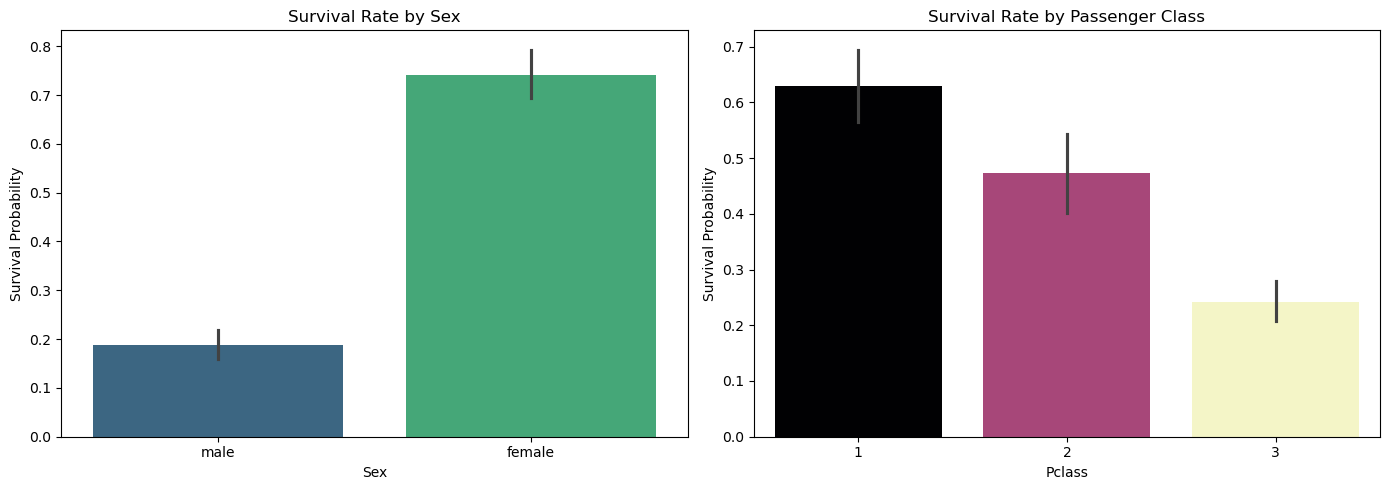

In [9]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Sex', y='Survived', hue='Sex', data=train_df, palette='viridis', legend=False)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Probability')
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=train_df, palette='magma', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.show()

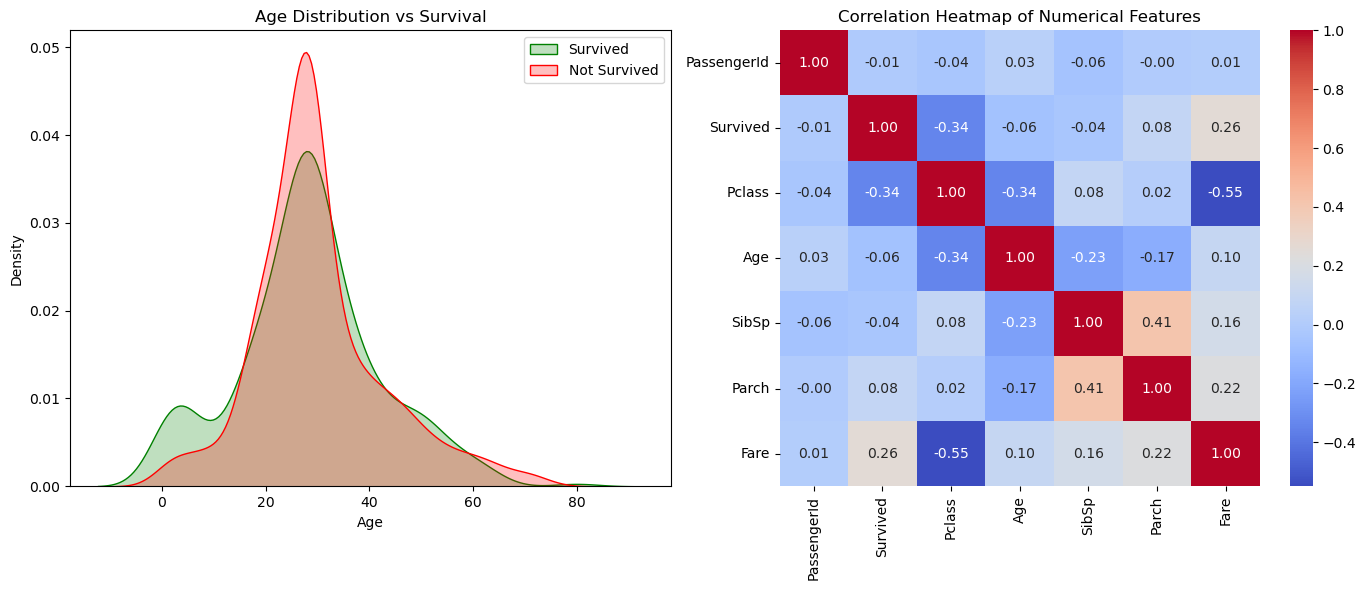

In [10]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(train_df[train_df['Survived'] == 1]['Age'], label='Survived', fill=True, color='green')
sns.kdeplot(train_df[train_df['Survived'] == 0]['Age'], label='Not Survived', fill=True, color='red')
plt.title('Age Distribution vs Survival')
plt.legend()
plt.subplot(1, 2, 2)
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

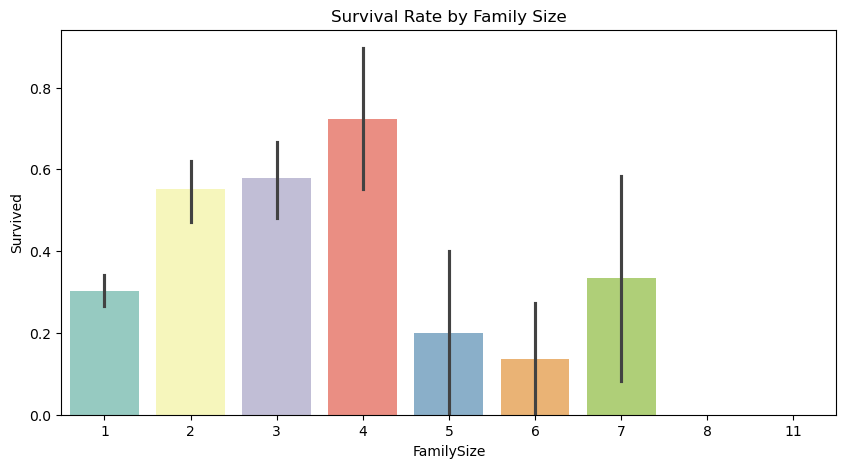

In [11]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
plt.figure(figsize=(10, 5))
sns.barplot(x='FamilySize', y='Survived', hue='FamilySize', data=train_df, palette='Set3', legend=False)
plt.title('Survival Rate by Family Size')
plt.show()

The journey began with simple data cleaning but quickly evolved into uncovering a deeper story hidden within the numbers. At first, the focus was on using Excel’s practical tools like Flash Fill and case correction functions to organize messy spreadsheets into structured, reliable records. However, working with the Titanic dataset in Python transformed the task from routine formatting to meaningful analysis. By addressing missing values, removing redundant columns, and refining the dataset, clear patterns began to surface. The findings showed that survival on the Titanic was far from random; it was closely linked to factors such as gender, age, and ticket class. Through visualizations, what started as rows of data became compelling evidence of social hierarchy and the “women and children first” protocol, offering a powerful, data-driven insight into one of history’s most tragic events.